<a href="https://colab.research.google.com/github/aboettcher-sig/orbit_unops/blob/main/docs/studies/03_sdg_notebooks/EE_embeddings_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip -q install earthengine-api

import ee
import numpy as np
import pandas as pd

In [3]:
from google.colab import userdata
cloud_project = userdata.get('cloud_project')

In [4]:
ee.Authenticate()

PROJECT = cloud_project

if PROJECT is None:
    ee.Initialize()
else:
    ee.Initialize(project=PROJECT)

In [45]:
# -------------------------------------------------------------------
# Settings
# -------------------------------------------------------------------
MAP_YEAR = 2019
YEAR_START = 2019
YEAR_END = 2025

SAMPLE_POINTS_PER_CLASS = 1000
DW_VALIDATION_POINTS_PER_CLASS = 1000

SAMPLE_SCALE = 10
EMBEDDING_SCALE = 10
POP_SCALE = 100

TREES = 100
SEED = 42
EPS = 1e-6

AOI = ee.Geometry.Rectangle(
    [-158.35, 21.25, -157.65, 21.75],
    # [-158.09751,21.3392,-158.04701, 21.37436],
    proj="EPSG:4326",
    geodesic=False,
)

EXPORT_FOLDER = "oahu_urban_growth"
EXPORT_CRS = "EPSG:32604"  # UTM zone 4N — Oahu
EXPORT_SCALE = 10

# -------------------------------------------------------------------
# Datasets
# -------------------------------------------------------------------
embeddings = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
wsf2019 = ee.ImageCollection("projects/sat-io/open-datasets/WSF/WSF_2019")
dynamic_world = ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
ghs_pop = ee.ImageCollection("JRC/GHSL/P2023A/GHS_POP")

DW_BANDS = [
    "water",
    "trees",
    "grass",
    "flooded_vegetation",
    "crops",
    "shrub_and_scrub",
    "built",
    "bare",
    "snow_and_ice",
]

DW_BUILT_INDEX = DW_BANDS.index("built")


In [46]:

# -------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------
def population_image_for_year(year):
    """Return the GHS-POP image at the nearest available epoch (5-year cadence)."""
    epochs = list(range(1975, 2031, 5))
    nearest = min(epochs, key=lambda e: abs(e - year))

    img = (
        ee.Image(f"JRC/GHSL/P2023A/GHS_POP/{nearest}")
        .select("population_count")
    )
    img = img.updateMask(img.gte(0)).rename(f"ghs_pop_{nearest}")
    return img


def inspection_stack_for_year(year):
    """Build a multi-band stack for visual QC of a single year."""
    rf_img = rf_images_by_year(year)              # p_urban, rf_urban
    dw_built = dynamic_world_built_by_year(year)  # dw_built
    pop_img = population_image_for_year(year)     # ghs_pop_<epoch>

    return (
        rf_img
        .addBands(dw_built)
        .addBands(pop_img)
        .toFloat()
        .clip(AOI)
        .set({"year": year})
    )


def start_export_for_year(year):
    stack = inspection_stack_for_year(year)
    desc = f"oahu_urban_stack_{year}"

    task = ee.batch.Export.image.toDrive(
        image=stack,
        description=desc,
        folder=EXPORT_FOLDER,
        fileNamePrefix=desc,
        region=AOI,
        scale=EXPORT_SCALE,
        crs=EXPORT_CRS,
        maxPixels=1e13,
        fileFormat="GeoTIFF",
        formatOptions={"cloudOptimized": True},
    )
    task.start()
    return task

def embeddings_by_year(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, "year")

    return (
        embeddings
        .filterDate(start, end)
        .filterBounds(AOI)
        .mosaic()
        .clip(AOI)
    )


def dynamic_world_built_by_year(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, "year")

    dw = (
        dynamic_world
        .filterDate(start, end)
        .filterBounds(AOI)
        .select(DW_BANDS)
        .median()
        .clip(AOI)
    )

    dw_class = (
        dw
        .toArray()
        .arrayArgmax()
        .arrayGet([0])
        .rename("dw_class")
        .toByte()
    )

    return dw_class.eq(DW_BUILT_INDEX).rename("dw_built").toByte()


def add_p_urban(feature):
    probs = ee.Array(feature.get("probabilities"))
    return feature.set("p_urban", ee.Number(probs.get([1])))


def add_error_fields(y_col):
    def inner(feature):
        y = ee.Number(feature.get(y_col))
        p = ee.Number(feature.get("p_urban"))
        pred = ee.Number(feature.get("classification"))

        err = p.subtract(y)

        return feature.set({
            "error": err,
            "abs_error": err.abs(),
            "sq_error": err.pow(2),
            "tp": pred.multiply(y),
            "fp": pred.multiply(ee.Number(1).subtract(y)),
            "tn": ee.Number(1).subtract(pred).multiply(ee.Number(1).subtract(y)),
            "fn": ee.Number(1).subtract(pred).multiply(y),
        })

    return inner


def add_total_error(y_col, mean_y):
    def inner(feature):
        y = ee.Number(feature.get(y_col))
        return feature.set("sq_total", y.subtract(mean_y).pow(2))

    return inner


def metrics(scored, y_col):
    n = ee.Number(scored.size())
    mean_y = ee.Number(scored.aggregate_mean(y_col))

    scored = scored.map(add_total_error(y_col, mean_y))

    sse = ee.Number(scored.aggregate_sum("sq_error"))
    sst = ee.Number(scored.aggregate_sum("sq_total"))

    tp = ee.Number(scored.aggregate_sum("tp"))
    fp = ee.Number(scored.aggregate_sum("fp"))
    tn = ee.Number(scored.aggregate_sum("tn"))
    fn = ee.Number(scored.aggregate_sum("fn"))

    return ee.Dictionary({
        "n": n,
        "mean_label": mean_y,
        "r2": ee.Number(1).subtract(sse.divide(sst.max(EPS))),
        "rmse": sse.divide(n.max(EPS)).sqrt(),
        "mae": ee.Number(scored.aggregate_sum("abs_error")).divide(n.max(EPS)),
        "bias": ee.Number(scored.aggregate_sum("error")).divide(n.max(EPS)),
        "accuracy": tp.add(tn).divide(n.max(EPS)),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    })


def rf_images_by_year(year):
    img = embeddings_by_year(year)

    p_urban = (
        img
        .classify(probability_classifier, "probabilities")
        .arrayGet([1])
        .rename("p_urban")
    )

    rf_class = (
        img
        .classify(classifier)
        .rename("rf_urban")
        .toByte()
    )

    return p_urban.addBands(rf_class)


def dynamic_world_validation_for_year(year):
    dw_built = dynamic_world_built_by_year(year)

    dw_sample = (
        dw_built
        .stratifiedSample(
            numPoints=DW_VALIDATION_POINTS_PER_CLASS,
            classBand="dw_built",
            region=AOI,
            scale=10,
            geometries=True,
            seed=SEED + year,
            tileScale=4,
        )
    )

    rf_img = rf_images_by_year(year)

    scored = (
        rf_img
        .sampleRegions(
            collection=dw_sample,
            properties=["dw_built"],
            scale=10,
            geometries=False,
            tileScale=4,
        )
        .filter(ee.Filter.notNull(["p_urban", "rf_urban", "dw_built"]))
        .map(lambda f: f.set("classification", f.get("rf_urban")))
        .map(add_error_fields("dw_built"))
    )

    out = metrics(scored, "dw_built").getInfo()
    out["year"] = year

    return out


def area_for_year(year):
    rf_img = rf_images_by_year(year)
    dw_built = dynamic_world_built_by_year(year)

    pixel_area = ee.Image.pixelArea()

    area_img = ee.Image.cat([
        pixel_area.updateMask(rf_img.select("rf_urban")).rename("rf_area_m2"),
        pixel_area.updateMask(dw_built).rename("dw_area_m2"),
    ])

    stats = area_img.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=AOI,
        scale=10,
        maxPixels=1e13,
        tileScale=4,
    )

    return {
        "year": year,
        "rf_area_m2": stats.get("rf_area_m2").getInfo(),
        "dw_area_m2": stats.get("dw_area_m2").getInfo(),
    }


def ghs_pop_years_in_range(start, end):
    # Epochs are fixed by the GHS-POP P2023A spec: 1975, 1980, ..., 2030.
    epochs = list(range(1975, 2031, 5))
    return [y for y in epochs if start <= y <= end]


def population_for_year(year):
    img = (
        ee.Image(f"JRC/GHSL/P2023A/GHS_POP/{year}")
        .select("population_count")
    )

    # Drop NoData / negative sentinels so fill values don't leak into the sum.
    img = img.updateMask(img.gte(0))

    total = img.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=AOI,
        scale=POP_SCALE,
        maxPixels=1e13,
        tileScale=4,
    ).get("population_count")

    pop_val = total.getInfo()

    # reduceRegion returns None when nothing valid intersects the geometry.
    if pop_val is None or not np.isfinite(pop_val) or pop_val < 0:
        pop_val = float("nan")

    return {"year": year, "population": pop_val}


def r2_np(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    keep = np.isfinite(x) & np.isfinite(y)
    x = x[keep]
    y = y[keep]

    sse = np.sum((y - x) ** 2)
    sst = np.sum((x - np.mean(x)) ** 2)

    return 1 - (sse / sst) if sst != 0 else np.nan


In [47]:


# -------------------------------------------------------------------
# WSF 2019 labels
# -------------------------------------------------------------------
label_img = (
    wsf2019
    .filterBounds(AOI)
    .mosaic()
    .gt(0)
    .unmask(0)
    .rename("b1")
    .toByte()
    .clip(AOI)
)

sample = label_img.stratifiedSample(
    numPoints=SAMPLE_POINTS_PER_CLASS,
    classBand="b1",
    region=AOI,
    scale=SAMPLE_SCALE,
    geometries=True,
    seed=SEED,
    tileScale=4,
)

map_year_img = embeddings_by_year(MAP_YEAR)
input_properties = map_year_img.bandNames()

labels_and_vectors = (
    map_year_img
    .sampleRegions(
        collection=sample,
        properties=["b1"],
        scale=EMBEDDING_SCALE,
        geometries=True,
        tileScale=4,
    )
    .filter(ee.Filter.notNull(input_properties))
    .filter(ee.Filter.inList("b1", [0, 1]))
)

with_random = labels_and_vectors.randomColumn(columnName="random", seed=SEED)

training_set = with_random.filter(ee.Filter.lt("random", 0.7))
validation_set = with_random.filter(ee.Filter.gte("random", 0.7))



In [48]:
training_set

In [49]:

# -------------------------------------------------------------------
# Train RF
# -------------------------------------------------------------------
classifier = (
    ee.Classifier
    .smileRandomForest(numberOfTrees=TREES, seed=SEED)
    .train(
        features=training_set,
        classProperty="b1",
        inputProperties=input_properties,
    )
)

probability_classifier = (
    ee.Classifier
    .smileRandomForest(numberOfTrees=TREES, seed=SEED)
    .setOutputMode("MULTIPROBABILITY")
    .train(
        features=training_set,
        classProperty="b1",
        inputProperties=input_properties,
    )
)

# -------------------------------------------------------------------
# WSF held-out validation
# -------------------------------------------------------------------
wsf_scored = (
    validation_set
    .classify(classifier)
    .classify(probability_classifier, "probabilities")
    .map(add_p_urban)
    .map(add_error_fields("b1"))
)

wsf_metrics = metrics(wsf_scored, "b1").getInfo()

# -------------------------------------------------------------------
# Dynamic World validation, annual urban area, GHS-POP totals
# -------------------------------------------------------------------
dw_metrics_records = []
area_records = []

for year in range(YEAR_START, YEAR_END + 1):
    dw_metrics_records.append(dynamic_world_validation_for_year(year))
    area_records.append(area_for_year(year))

pop_records = [
    population_for_year(y)
    for y in ghs_pop_years_in_range(YEAR_START, YEAR_END)
]

# -------------------------------------------------------------------
# Assemble dataframes
# -------------------------------------------------------------------
wsf_metrics_df = pd.DataFrame([wsf_metrics])
dw_metrics_df = pd.DataFrame(dw_metrics_records)
area_df = pd.DataFrame(area_records)
pop_df = pd.DataFrame(pop_records) if pop_records else pd.DataFrame(columns=["year", "population"])

area_df["rf_area_km2"] = area_df["rf_area_m2"] / 1e6
area_df["dw_area_km2"] = area_df["dw_area_m2"] / 1e6
area_df["rf_minus_dw_km2"] = area_df["rf_area_km2"] - area_df["dw_area_km2"]

area_r2 = r2_np(area_df["dw_area_km2"], area_df["rf_area_km2"])

# Join GHS-POP epochs onto the annual area series and interpolate
combined_df = area_df.merge(pop_df, on="year", how="left").sort_values("year").reset_index(drop=True)
combined_df["population_interp"] = (
    combined_df["population"]
    .interpolate(method="linear", limit_direction="both")
)

# Avoid divide-by-zero or NaN propagation in per-capita columns.
safe_pop = combined_df["population_interp"].where(combined_df["population_interp"] > 0)

combined_df["rf_km2_per_1k"] = combined_df["rf_area_km2"] / (safe_pop / 1000)
combined_df["dw_km2_per_1k"] = combined_df["dw_area_km2"] / (safe_pop / 1000)

# Growth-rate summary between first and last GHS-POP epochs in range
epoch_df = combined_df.dropna(subset=["population"]).sort_values("year")

if len(epoch_df) >= 2:
    first, last = epoch_df.iloc[0], epoch_df.iloc[-1]
    span = int(last["year"] - first["year"])

    pop_growth_total = last["population"] / first["population"] - 1
    rf_growth_total = last["rf_area_km2"] / first["rf_area_km2"] - 1
    dw_growth_total = last["dw_area_km2"] / first["dw_area_km2"] - 1

    pop_cagr = (last["population"] / first["population"]) ** (1 / span) - 1
    rf_cagr = (last["rf_area_km2"] / first["rf_area_km2"]) ** (1 / span) - 1
    dw_cagr = (last["dw_area_km2"] / first["dw_area_km2"]) ** (1 / span) - 1

    rf_elasticity = rf_growth_total / pop_growth_total if pop_growth_total else float("nan")
    dw_elasticity = dw_growth_total / pop_growth_total if pop_growth_total else float("nan")

    growth_summary = pd.DataFrame([{
        "year_start": int(first["year"]),
        "year_end": int(last["year"]),
        "pop_start": first["population"],
        "pop_end": last["population"],
        "pop_growth_total_pct": pop_growth_total * 100,
        "pop_cagr_pct": pop_cagr * 100,
        "rf_growth_total_pct": rf_growth_total * 100,
        "rf_cagr_pct": rf_cagr * 100,
        "dw_growth_total_pct": dw_growth_total * 100,
        "dw_cagr_pct": dw_cagr * 100,
        "rf_elasticity_vs_pop": rf_elasticity,
        "dw_elasticity_vs_pop": dw_elasticity,
    }])
else:
    growth_summary = pd.DataFrame()

In [50]:

# -------------------------------------------------------------------
# Print results
# -------------------------------------------------------------------
print("\nWSF 2019 held-out validation")
print(
    wsf_metrics_df[
        ["n", "mean_label", "r2", "rmse", "mae", "bias", "accuracy", "tp", "fp", "tn", "fn"]
    ].round(4).to_string(index=False)
)

print("\nDynamic World annual validation")
print(
    dw_metrics_df[
        ["year", "n", "mean_label", "r2", "rmse", "mae", "bias", "accuracy", "tp", "fp", "tn", "fn"]
    ].round(4).to_string(index=False)
)

print("\nAnnual area and population")
print(
    combined_df[
        ["year", "rf_area_km2", "dw_area_km2", "rf_minus_dw_km2",
         "population", "population_interp",
         "rf_km2_per_1k", "dw_km2_per_1k"]
    ].round(4).to_string(index=False)
)

print("\nArea R2 against Dynamic World")

if not growth_summary.empty:
    print("\nPopulation vs urban-area growth (GHS-POP epochs only)")
    print(growth_summary.round(4).T.to_string())


WSF 2019 held-out validation
  n  mean_label     r2   rmse    mae    bias  accuracy  tp  fp  tn  fn
548      0.5693 0.8747 0.1753 0.0871 -0.0061    0.9672 307  13 223   5

Dynamic World annual validation
 year    n  mean_label     r2   rmse    mae    bias  accuracy  tp  fp  tn  fn
 2019 1838      0.5441 0.7956 0.2252 0.1263 -0.0786    0.9157 851   6 832 149
 2020 1828      0.5470 0.8083 0.2179 0.1239 -0.0731    0.9294 877   6 822 123
 2021 1840      0.5435 0.8203 0.2111 0.1247 -0.0707    0.9424 903   9 831  97
 2022 1836      0.5447 0.7963 0.2248 0.1306 -0.0756    0.9297 880   9 827 120
 2023 1823      0.5485 0.8148 0.2142 0.1285 -0.0709    0.9380 897  10 813 103
 2024 1828      0.5470 0.7709 0.2383 0.1392 -0.0926    0.9070 835   5 823 165
 2025 1843      0.5426 0.8042 0.2205 0.1294 -0.0742    0.9333 883   6 837 117

Annual area and population
 year  rf_area_km2  dw_area_km2  rf_minus_dw_km2   population  population_interp  rf_km2_per_1k  dw_km2_per_1k
 2019     297.1568     322.3933 


Annual area estimates
 year  dw_area_km2  rf_area_km2
 2019     322.3933     297.1568
 2020     326.1534     313.8622
 2021     331.7267     326.1505
 2022     334.9374     317.7317
 2023     332.3516     324.0378
 2024     333.1105     305.9382
 2025     334.8257     329.5736

Area agreement metrics
        comparison  n  correlation       r2  rmse_km2  mae_km2  bias_km2
rf_area_vs_dw_area  7       0.6919 -13.5325    16.691  14.4354  -14.4354


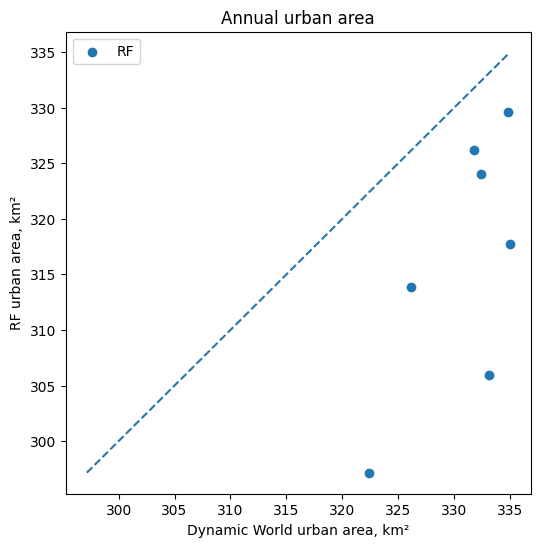

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Uses area_df from the previous cell.
# Expected columns:
# year, rf_area_km2, dw_area_km2

plot_df = area_df.sort_values("year").copy()

def compare_area(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    keep = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[keep]
    y_pred = y_pred[keep]

    err = y_pred - y_true
    sse = np.sum(err ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)

    return {
        "n": len(y_true),
        "correlation": np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan,
        "r2": 1 - (sse / sst) if sst != 0 else np.nan,
        "rmse_km2": np.sqrt(np.mean(err ** 2)),
        "mae_km2": np.mean(np.abs(err)),
        "bias_km2": np.mean(err),
    }

metrics_df = pd.DataFrame([
    {
        "comparison": "rf_area_vs_dw_area",
        **compare_area(plot_df["dw_area_km2"], plot_df["rf_area_km2"])
    }
])

print("\nAnnual area estimates")
print(
    plot_df[
        [
            "year",
            "dw_area_km2",
            "rf_area_km2",
        ]
    ].round(4).to_string(index=False)
)

print("\nArea agreement metrics")
print(metrics_df.round(4).to_string(index=False))

plt.figure(figsize=(6, 6))
plt.scatter(plot_df["dw_area_km2"], plot_df["rf_area_km2"], label="RF")

xmin = min(
    plot_df["dw_area_km2"].min(),
    plot_df["rf_area_km2"].min()
)

xmax = max(
    plot_df["dw_area_km2"].max(),
    plot_df["rf_area_km2"].max()
)

plt.plot([xmin, xmax], [xmin, xmax], linestyle="--")
plt.xlabel("Dynamic World urban area, km²")
plt.ylabel("RF urban area, km²")
plt.title("Annual urban area")
plt.legend()
plt.show()


Year-over-year area deltas
 year  dw_delta_km2  rf_delta_km2
 2020        3.7601       16.7055
 2021        5.5733       12.2883
 2022        3.2107       -8.4188
 2023       -2.5859        6.3061
 2024        0.7590      -18.0996
 2025        1.7151       23.6354

Delta agreement metrics
          comparison  n  correlation       r2  rmse_km2  mae_km2  bias_km2
rf_delta_vs_dw_delta  6       0.2128 -30.6157   14.5094  13.4935    3.3307


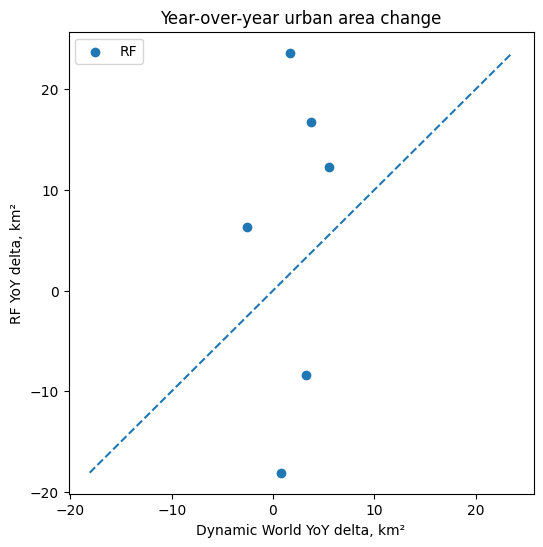

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Uses area_df from the previous cell.
# Expected columns:
# year, rf_area_km2, dw_area_km2

delta_df = area_df.sort_values("year").copy()

delta_df["dw_delta_km2"] = delta_df["dw_area_km2"].diff()
delta_df["rf_delta_km2"] = delta_df["rf_area_km2"].diff()

delta_df = delta_df.dropna().reset_index(drop=True)

def compare_delta(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    keep = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[keep]
    y_pred = y_pred[keep]

    err = y_pred - y_true
    sse = np.sum(err ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)

    return {
        "n": len(y_true),
        "correlation": np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan,
        "r2": 1 - (sse / sst) if sst != 0 else np.nan,
        "rmse_km2": np.sqrt(np.mean(err ** 2)),
        "mae_km2": np.mean(np.abs(err)),
        "bias_km2": np.mean(err),
    }

metrics_df = pd.DataFrame([
    {
        "comparison": "rf_delta_vs_dw_delta",
        **compare_delta(delta_df["dw_delta_km2"], delta_df["rf_delta_km2"])
    }
])

print("\nYear-over-year area deltas")
print(
    delta_df[
        [
            "year",
            "dw_delta_km2",
            "rf_delta_km2",
        ]
    ].round(4).to_string(index=False)
)

print("\nDelta agreement metrics")
print(metrics_df.round(4).to_string(index=False))

plt.figure(figsize=(6, 6))
plt.scatter(delta_df["dw_delta_km2"], delta_df["rf_delta_km2"], label="RF")

xmin = min(
    delta_df["dw_delta_km2"].min(),
    delta_df["rf_delta_km2"].min()
)

xmax = max(
    delta_df["dw_delta_km2"].max(),
    delta_df["rf_delta_km2"].max()
)

plt.plot([xmin, xmax], [xmin, xmax], linestyle="--")
plt.xlabel("Dynamic World YoY delta, km²")
plt.ylabel("RF YoY delta, km²")
plt.title("Year-over-year urban area change")
plt.legend()
plt.show()


Year-over-year area deltas
 year  dw_delta_km2  rf_delta_km2
 2020        3.7601       16.7055
 2021        5.5733       12.2883
 2022        3.2107       -8.4188
 2023       -2.5859        6.3061
 2024        0.7590      -18.0996
 2025        1.7151       23.6354

Delta agreement metrics
          comparison  n  correlation       r2  rmse_km2  mae_km2  bias_km2
rf_delta_vs_dw_delta  6       0.2128 -30.6157   14.5094  13.4935    3.3307


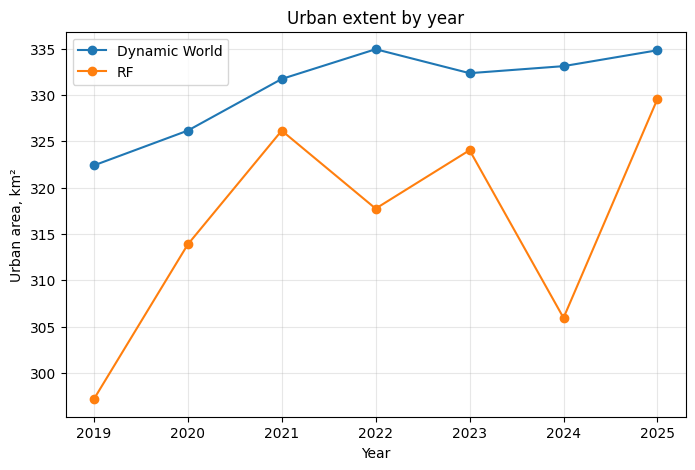

In [53]:
import numpy as np
import pandas as pd

# Uses area_df from the previous cell.
# Expected columns:
# year, rf_area_km2, dw_area_km2

delta_df = area_df.sort_values("year").copy()

delta_df["dw_delta_km2"] = delta_df["dw_area_km2"].diff()
delta_df["rf_delta_km2"] = delta_df["rf_area_km2"].diff()

delta_df = delta_df.dropna().reset_index(drop=True)

def compare_delta(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    keep = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[keep]
    y_pred = y_pred[keep]

    err = y_pred - y_true
    sse = np.sum(err ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)

    return {
        "n": len(y_true),
        "correlation": np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan,
        "r2": 1 - (sse / sst) if sst != 0 else np.nan,
        "rmse_km2": np.sqrt(np.mean(err ** 2)),
        "mae_km2": np.mean(np.abs(err)),
        "bias_km2": np.mean(err),
    }

metrics_df = pd.DataFrame([
    {
        "comparison": "rf_delta_vs_dw_delta",
        **compare_delta(delta_df["dw_delta_km2"], delta_df["rf_delta_km2"])
    }
])

print("\nYear-over-year area deltas")
print(
    delta_df[
        [
            "year",
            "dw_delta_km2",
            "rf_delta_km2",
        ]
    ].round(4).to_string(index=False)
)

print("\nDelta agreement metrics")
print(metrics_df.round(4).to_string(index=False))

extent_df = area_df.sort_values("year").reset_index(drop=True)

plt.figure(figsize=(8, 5))
plt.plot(extent_df["year"], extent_df["dw_area_km2"], marker="o", label="Dynamic World")
plt.plot(extent_df["year"], extent_df["rf_area_km2"], marker="o", label="RF")
plt.xlabel("Year")
plt.ylabel("Urban area, km²")
plt.title("Urban extent by year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Year-over-year area deltas
 year  dw_delta_km2  rf_delta_km2
 2020        3.7601       16.7055
 2021        5.5733       12.2883
 2022        3.2107       -8.4188
 2023       -2.5859        6.3061
 2024        0.7590      -18.0996
 2025        1.7151       23.6354

Delta agreement metrics
          comparison  n  correlation       r2  rmse_km2  mae_km2  bias_km2
rf_delta_vs_dw_delta  6       0.2128 -30.6157   14.5094  13.4935    3.3307


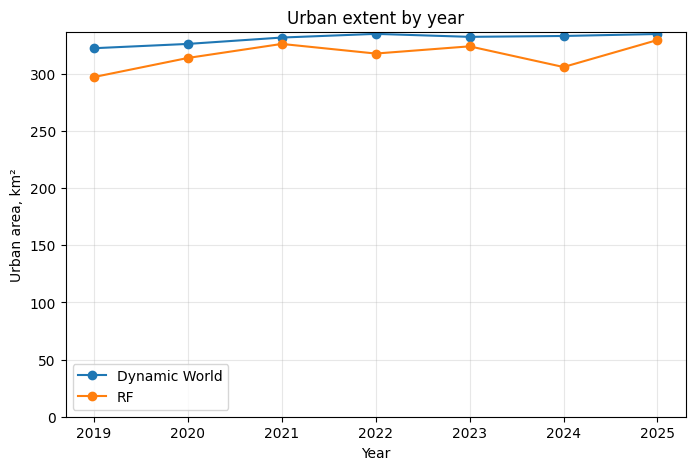

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Uses area_df from the previous cell.
# Expected columns:
# year, rf_area_km2, dw_area_km2

delta_df = area_df.sort_values("year").copy()

delta_df["dw_delta_km2"] = delta_df["dw_area_km2"].diff()
delta_df["rf_delta_km2"] = delta_df["rf_area_km2"].diff()

delta_df = delta_df.dropna().reset_index(drop=True)

def compare_delta(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    keep = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[keep]
    y_pred = y_pred[keep]

    err = y_pred - y_true
    sse = np.sum(err ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)

    return {
        "n": len(y_true),
        "correlation": np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan,
        "r2": 1 - (sse / sst) if sst != 0 else np.nan,
        "rmse_km2": np.sqrt(np.mean(err ** 2)),
        "mae_km2": np.mean(np.abs(err)),
        "bias_km2": np.mean(err),
    }

metrics_df = pd.DataFrame([
    {
        "comparison": "rf_delta_vs_dw_delta",
        **compare_delta(delta_df["dw_delta_km2"], delta_df["rf_delta_km2"])
    }
])

print("\nYear-over-year area deltas")
print(
    delta_df[
        [
            "year",
            "dw_delta_km2",
            "rf_delta_km2",
        ]
    ].round(4).to_string(index=False)
)

print("\nDelta agreement metrics")
print(metrics_df.round(4).to_string(index=False))

extent_df = area_df.sort_values("year").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(extent_df["year"], extent_df["dw_area_km2"], marker="o", label="Dynamic World")
ax.plot(extent_df["year"], extent_df["rf_area_km2"], marker="o", label="RF")
ax.set_xlabel("Year")
ax.set_ylabel("Urban area, km²")
ax.set_title("Urban extent by year")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.show()

In [2]:
# import ee
# import geemap

# # Oahu bbox
# bbox = ee.Geometry.BBox(-158.35, 21.25, -157.65, 21.75)

# # Available epochs: 1975, 1980, 1985, ..., 2020, 2025, 2030 (5-year steps)
# year_a, year_b = 1990, 2020

# img_a = ee.Image(f'JRC/GHSL/P2023A/GHS_POP/{year_a}').select('population_count').clip(bbox)
# img_b = ee.Image(f'JRC/GHSL/P2023A/GHS_POP/{year_b}').select('population_count').clip(bbox)

# # Mask zero-pop cells so basemap shows through
# img_a_m = img_a.updateMask(img_a.gt(0))
# img_b_m = img_b.updateMask(img_b.gt(0))

# vis = {
#     'min': 0.0,
#     'max': 100.0,
#     'palette': ['000004', '320A5A', '781B6C', 'BB3654',
#                 'EC6824', 'FBB41A', 'FCFFA4'],  # inferno-ish
# }

# # Side-by-side split map
# m = geemap.Map()
# m.center_object(bbox, 10)

# left  = geemap.ee_tile_layer(img_a_m, vis, f'Population {year_a}')
# right = geemap.ee_tile_layer(img_b_m, vis, f'Population {year_b}')
# m.split_map(left_layer=left, right_layer=right)

# # Optional: absolute change layer
# delta = img_b.subtract(img_a).rename('delta_pop')
# delta_vis = {
#     'min': -50, 'max': 50,
#     'palette': ['2166ac', '67a9cf', 'd1e5f0', 'f7f7f7',
#                 'fddbc7', 'ef8a62', 'b2182b'],  # diverging RdBu
# }
# m.add_layer(delta.updateMask(delta.abs().gt(1)), delta_vis,
#             f'Δ population {year_a}→{year_b}', False)

# # Quick zonal totals over the bbox
# for yr, im in [(year_a, img_a), (year_b, img_b)]:
#     total = im.reduceRegion(
#         reducer=ee.Reducer.sum(),
#         geometry=bbox,
#         scale=100,
#         maxPixels=1e9,
#     ).get('population_count')
#     print(f'{yr} total population in bbox: {total.getInfo():,.0f}')

# m

In [58]:
export_tasks = []
for year in range(YEAR_START, YEAR_END + 1):
    task = start_export_for_year(year)
    export_tasks.append((year, task.id, task.status().get("description")))

print("\nDrive export tasks started")
for year, tid, desc in export_tasks:
    print(f"  {year}  {desc}  task_id={tid}")
print(f"Files will land in Drive folder: {EXPORT_FOLDER}/")
print("Monitor with: ee.batch.Task.list() or the Earth Engine Tasks tab.")


Drive export tasks started
  2019  oahu_urban_stack_2019  task_id=SIRJKTM5CYMCXNR5D4XTYZAS
  2020  oahu_urban_stack_2020  task_id=KNHL2X7CRIFSLVXBSCQ32A7G
  2021  oahu_urban_stack_2021  task_id=PSW565OZHOPIRZAHZE742F6N
  2022  oahu_urban_stack_2022  task_id=G4WEK33FGYPV4BMUESUFW5PD
  2023  oahu_urban_stack_2023  task_id=DI7NZOJ2B4CGRB6JSKIYOJQU
  2024  oahu_urban_stack_2024  task_id=DICPHGLD4ATBDJYFF4GXMJQX
  2025  oahu_urban_stack_2025  task_id=TQAIVVETXTXJF2EA3UXKBLSY
Files will land in Drive folder: oahu_urban_growth/
Monitor with: ee.batch.Task.list() or the Earth Engine Tasks tab.


In [59]:
 ee.batch.Task.list()

[<Task TQAIVVETXTXJF2EA3UXKBLSY EXPORT_IMAGE: oahu_urban_stack_2025 (READY)>,
 <Task DICPHGLD4ATBDJYFF4GXMJQX EXPORT_IMAGE: oahu_urban_stack_2024 (READY)>,
 <Task DI7NZOJ2B4CGRB6JSKIYOJQU EXPORT_IMAGE: oahu_urban_stack_2023 (READY)>,
 <Task G4WEK33FGYPV4BMUESUFW5PD EXPORT_IMAGE: oahu_urban_stack_2022 (READY)>,
 <Task PSW565OZHOPIRZAHZE742F6N EXPORT_IMAGE: oahu_urban_stack_2021 (READY)>,
 <Task KNHL2X7CRIFSLVXBSCQ32A7G EXPORT_IMAGE: oahu_urban_stack_2020 (RUNNING)>,
 <Task SIRJKTM5CYMCXNR5D4XTYZAS EXPORT_IMAGE: oahu_urban_stack_2019 (RUNNING)>,
 <Task NJ625RWS7BH7H775M7BFGMWA EXPORT_IMAGE: oahu_urban_stack_2025 (COMPLETED)>,
 <Task FRFZIGEPGQEAY5AVKV3SGMGA EXPORT_IMAGE: oahu_urban_stack_2024 (COMPLETED)>,
 <Task FM3L52LTQCWRK24TR667IO2S EXPORT_IMAGE: oahu_urban_stack_2023 (COMPLETED)>,
 <Task 6MS72DVF2NMCCZADLBLCUUYN EXPORT_IMAGE: oahu_urban_stack_2022 (COMPLETED)>,
 <Task 24QCTWZKDDGCUE5NLIZY5OLR EXPORT_IMAGE: oahu_urban_stack_2021 (COMPLETED)>,
 <Task 44FMMJ4QOU6VZRDC557LDLNZ EXPORT_I